Best-fit focal length f = 17.862 mm
Chi-squared = 2604.008, Reduced chi-squared = 186.001


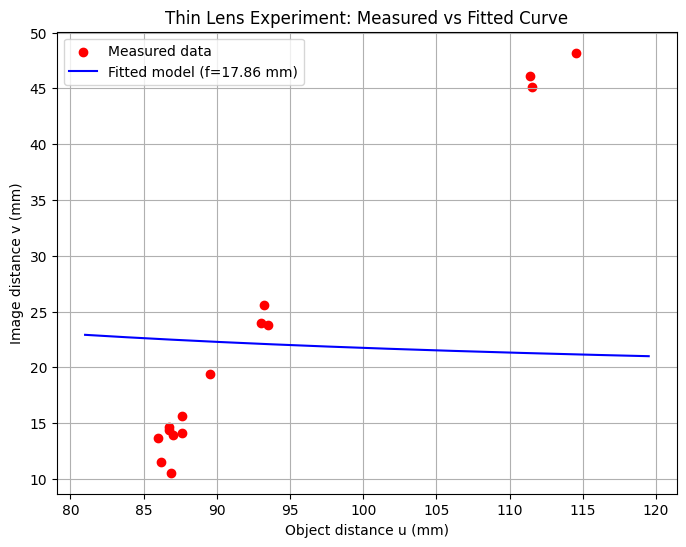

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

data = {
    62: [(93.2, 25.63), (93.0, 23.93), (93.5, 23.76)],
    67: [(86.2, 11.49), (86.0, 13.67), (87.0, 13.93)],
    70: [(86.9, 10.56), (87.6, 14.11), (86.7, 14.39)],
    60: [(114.5, 48.19), (111.4, 46.12), (111.5, 45.16)],
    65: [(86.7, 14.66), (89.5, 19.37), (87.6, 15.67)],
}

def focal_length(u, v):
    return (u * v) / (u + v)

def v_pred(u, f):
    return (f * u) / (u - f)

def chi_squared(f, u_vals, v_vals, sigma=1.0):
    v_calc = v_pred(u_vals, f)
    residuals = (v_vals - v_calc) / sigma
    return np.sum(residuals**2)


all_u, all_v, all_f = [], [], []

for lens, trials in data.items():
    for u, v in trials:
        all_u.append(u)
        all_v.append(v)
        all_f.append(focal_length(u, v))

all_u = np.array(all_u)
all_v = np.array(all_v)
all_f = np.array(all_f)

initial_guess = np.mean(all_f)
res = minimize(lambda f: chi_squared(f[0], all_u, all_v, sigma=1.0),
               x0=[initial_guess], bounds=[(1e-6, None)])
f_best = res.x[0]
chi2_min = res.fun
dof = len(all_u) - 1
red_chi2 = chi2_min / dof

print(f"Best-fit focal length f = {f_best:.3f} mm")
print(f"Chi-squared = {chi2_min:.3f}, Reduced chi-squared = {red_chi2:.3f}")

plt.figure(figsize=(8,6))

plt.scatter(all_u, all_v, color="red", label="Measured data")

u_range = np.linspace(min(all_u)-5, max(all_u)+5, 500)
v_fit = v_pred(u_range, f_best)
plt.plot(u_range, v_fit, 'b-', label=f"Fitted model (f={f_best:.2f} mm)")

plt.xlabel("Object distance u (mm)")
plt.ylabel("Image distance v (mm)")
plt.title("Thin Lens Experiment: Measured vs Fitted Curve")
plt.legend()
plt.grid(True)

plt.show()